In [3]:
import torch
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

import numpy as np
import json
import gdown
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
class PlanesDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Решейп из плоского вектора 1200 (20*20*3) в (3, 20, 20)
        img = self.data[idx].reshape(3, 20, 20).astype(np.float32) / 255.0
        img = torch.from_numpy(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label

In [6]:
with open(output, 'r') as f:
    dataset = json.load(f)

X = np.array(dataset['data'])
y = np.array(dataset['labels'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_ds = PlanesDataset(X_train, y_train)
test_ds = PlanesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [10]:
len(train_ds)

25600

In [11]:
class PlanesCNN(nn.Module):
    def __init__(self, activation_func=nn.Mish()):
        super(PlanesCNN, self).__init__()
        self.features = nn.Sequential(
            #  20x20 to 10x10 
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            activation_func,
            nn.MaxPool2d(2),
            
            # 10x10 to 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            activation_func,
            nn.MaxPool2d(2),
            
            # 5x5 tp 2x2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            activation_func,
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            activation_func,
            nn.Dropout(0.5), # Борьба с оверфиттингом
            # финальный слой
            nn.Linear(256, 2) # Бинарная классификация
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


Epoch 01 | Train Acc: 93.8% | Test Acc: 94.5%
Epoch 02 | Train Acc: 97.5% | Test Acc: 93.0%
Epoch 03 | Train Acc: 98.1% | Test Acc: 98.3%
Epoch 04 | Train Acc: 98.7% | Test Acc: 97.9%
Epoch 05 | Train Acc: 98.8% | Test Acc: 98.5%
Epoch 06 | Train Acc: 99.1% | Test Acc: 98.2%
Epoch 07 | Train Acc: 99.2% | Test Acc: 96.8%
Epoch 08 | Train Acc: 99.2% | Test Acc: 98.3%
Epoch 09 | Train Acc: 99.3% | Test Acc: 94.9%
Epoch 10 | Train Acc: 99.5% | Test Acc: 98.5%
Epoch 11 | Train Acc: 99.5% | Test Acc: 98.5%
Epoch 12 | Train Acc: 99.5% | Test Acc: 98.3%
Epoch 13 | Train Acc: 99.6% | Test Acc: 98.4%
Epoch 14 | Train Acc: 99.6% | Test Acc: 98.4%
Epoch 15 | Train Acc: 99.7% | Test Acc: 98.7%


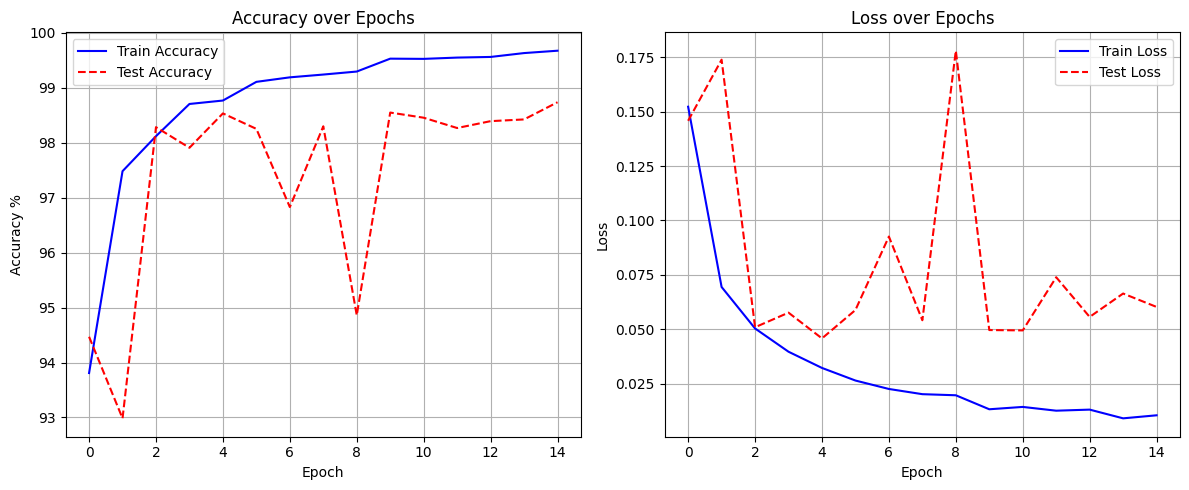

In [13]:
import matplotlib.pyplot as plt

model = PlanesCNN()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3)

def train_model(model, train_loader, test_loader, epochs=15):
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        # --- PHASE: TRAINING ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100. * correct / total)

        # --- PHASE: TESTING/VALIDATION ---
        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['test_loss'].append(test_loss / len(test_loader))
        history['test_acc'].append(100. * correct / total)
        
        print(f"Epoch {epoch+1:02d} | Train Acc: {history['train_acc'][-1]:.1f}% | Test Acc: {history['test_acc'][-1]:.1f}%")
    
    return history

# Запуск
history = train_model(model, train_loader, test_loader)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(12, 5))

# График Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['test_acc'], label='Test Accuracy', color='red', linestyle='--')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True)

# График Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['test_loss'], label='Test Loss', color='red', linestyle='--')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


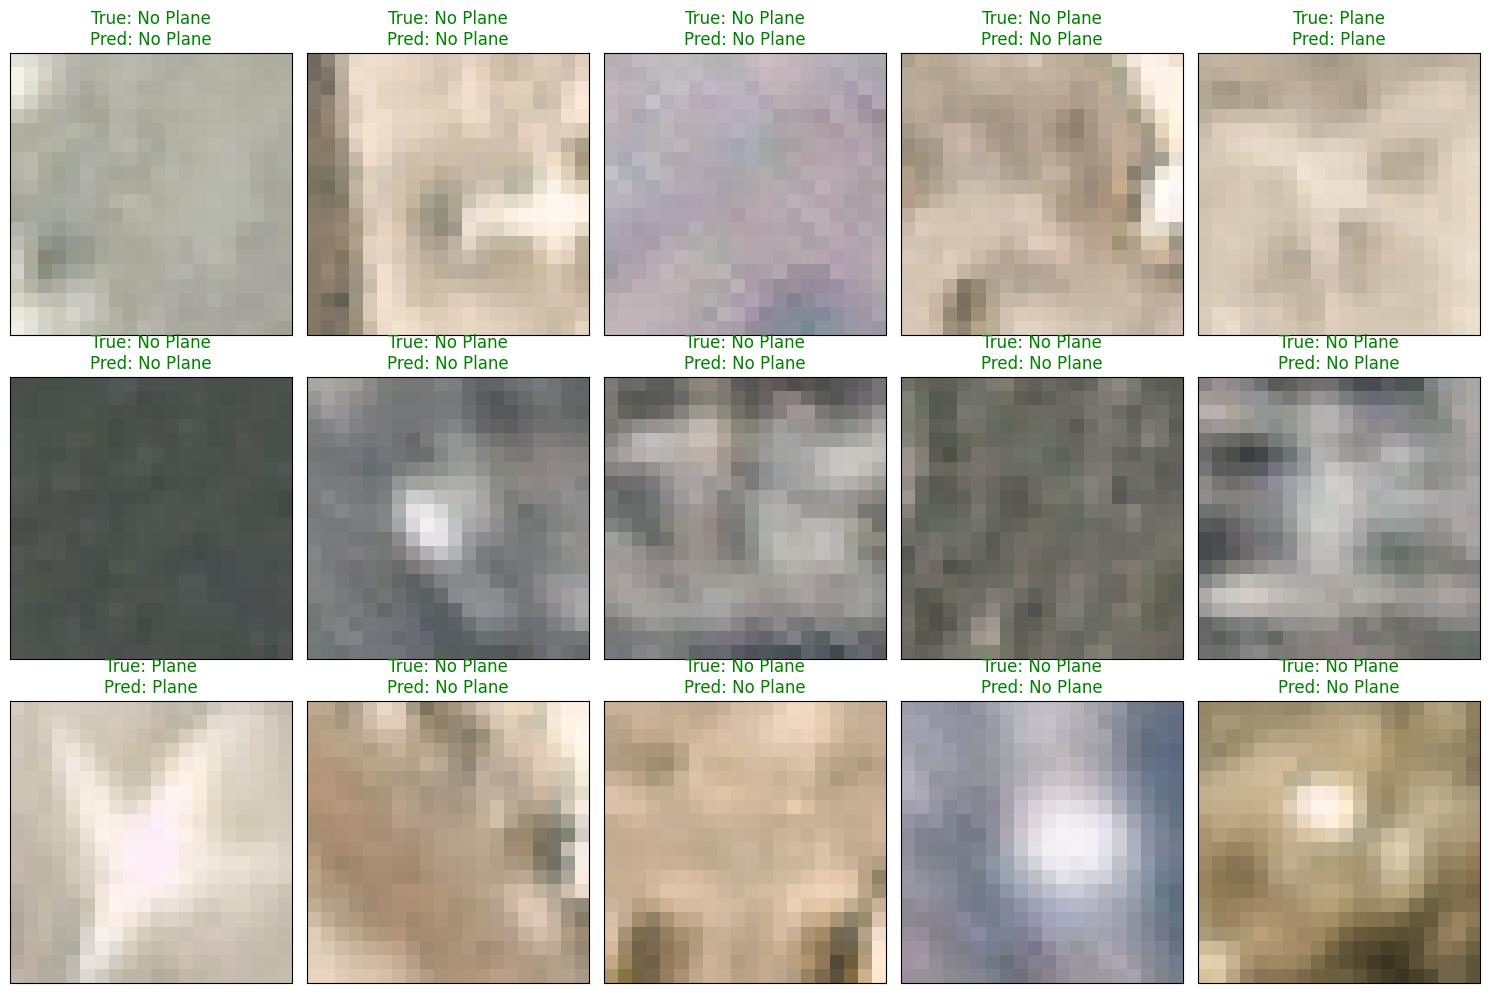

In [15]:

def visualize_predictions(model, test_loader, num_images=15):
    model.eval()
    images_list, labels_list, preds_list = [], [], []
    
    # Собираем данные из тестового лоадера
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            images_list.append(images)
            labels_list.append(labels)
            preds_list.append(predicted)
            
            if len(torch.cat(images_list)) >= num_images:
                break
                
    images_all = torch.cat(images_list)[:num_images]
    labels_all = torch.cat(labels_list)[:num_images]
    preds_all = torch.cat(preds_list)[:num_images]

    classes = ['No Plane', 'Plane']
    fig = plt.figure(figsize=(15, 10))
    for i in range(num_images):
        ax = fig.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
        
        # Конвертируем из (C, H, W) в (H, W, C) для imshow
        img = images_all[i].permute(1, 2, 0).cpu().numpy()
        # Если была нормализация, тут можно добавить де-нормализацию, 
        # но для PlanesNet обычно хватает простого клиппинга:
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        
        target = labels_all[i].item()
        pred = preds_all[i].item()
        
        # Зеленый если угадали, красный если ошибка
        color = 'green' if target == pred else 'red'
        
        ax.set_title(f"True: {classes[target]}\nPred: {classes[pred]}", color=color)

    plt.tight_layout()
    plt.show()

# Вызываем после обучения
visualize_predictions(model, test_loader)
